# AI-Datacenter-Basket — a quantitative teardown 🔬
### Equal-weight basket vs SPY & QQQ · HAC *t* of the spread · a theme-beta (equal-field) control · the ex-post-selection placebo · the random-basket distribution · a planted-edge synthetic control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Ride_the_build--out%3F: Busted](https://img.shields.io/badge/Ride_the_build--out%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). We separate the two things "buy the build-out" fuses: a **real AI-era spread** from the **after-the-fact selection** that named the basket. The basket-minus-market spread is large and significant on the tape (that is not in dispute); the decisive object is the **decomposition** — how much of it survives once you account for (a) the candidate field itself being survivorship-selected and (b) the eight being the hindsight top of it.

> ⚠️ **Data + look-ahead note.** yfinance monthly **total return**, a 30-name datacenter/power field + SPY + QQQ, **2022-02→2026-05** (post-spin tickers CEG/VST set the start — one short AI-capex regime). Both the field and the eight-name membership are *current-membership projected back* (look-ahead + survivorship; named on the Signal axis). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ai_datacenter_basket import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RETS, BENCH = data.load_real(allow_lookahead_selection=True)   # look-ahead is the SUBJECT
    RACE = st.race(RETS, BENCH, data.BASKET, k=8, n_draws=2000, cost_bps=10.0,
                   allow_lookahead_selection=True)
else:
    RETS = BENCH = RACE = None
print("real datacenter panel cache present:", HAVE_REAL,
      "| field names:", (0 if RETS is None else RETS.shape[1]))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2022-02', 'end': '2026-05', 'months': 52, 'years': 4.3, 'n_field': 30, 'fp': '7d69ca333d53', 'legs': {'basket': (71.7, 1.65, -21.7), 'spy': (14.3, 0.91, -20.2), 'qqq': (18.5, 0.91, -26.1), 'field': (38.8, 1.55, -16.7), 'expost': (83.7, 1.78, -20.3)}, 'basket_net': 71.5, 't_spy': (47.1, 3.19, 52), 't_qqq': (42.5, 3.12, 52), 't_eqf': (26.0, 2.37, 52), 'basket_spread': 57.4, 'expost_spread': 69.4, 'selection_share': 121, 'pctile': 100.0, 'rand_mean': 23.8, 'rand_median': 23.6, 'expost_members': ['VRT', 'MU', 'SMCI', 'NVDA', 'AVGO', 'DELL', 'VST', 'PWR'], 'names': [('VRT', 69.4, 2.59), ('ANET', 31.9, 2.38), ('CEG', 38.3, 2.18), ('NVDA', 48.2, 2.17), ('VST', 43.4, 2.04), ('SMCI', 84.6, 1.67), ('DELL', 48.9, 1.51), ('ETN', 12.5, 1.27)], 'syn': [(0.0, 4.5, 1.71, 14.3), (0.012, 17.5, 5.77, 21.0)]}


real datacenter panel cache present: True | field names: 30


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Basket−SPY **+47%/yr**, HAC **t = 3.19** (n=52); still **t = 3.12** vs QQQ and **t = 2.37** vs the equal-weight field. Real on the tape — but look-ahead-selected on one ~4-year regime. |
| **Tradability** | `MIRAGE` | Ex-post 'pick 8 winners' reproduces **121%** of the spread; the basket is the **100th percentile** of 2,000 random baskets; a *blind* eight already beats SPY by **+24%/yr**. Costs immaterial — **selection**, not friction, kills it. |
| **Ride the build-out?** | `BUSTED` | The +57%/yr decomposes into ≈+24%/yr (the field was hot, survivorship) + ≈+34%/yr (hand-picking its winners). Neither is forward-specifiable. Study 355 (Mag-7), thematic edition. |

> 💡 In plain words: the basket really did out-earn — because it's the realised top of a field that itself only contains survivors. Strip both and there's no tilt a 2019 investor could have *named*.

## 1 · The claim, steelmanned

Let $b$ be the eight-name basket (equal-weight, monthly-rebalanced) and $m$ a benchmark (SPY or QQQ). Write the per-month spread $d_t = r^b_t - r^m_t$ (both legs fully invested, so $d_t$ *is* the excess-of-each-other return).

- **H₁ (the basket out-earns).** $\mathbb{E}[d_t] > 0$ under autocorrelation-robust inference — a real spread over the market and the tech tape.
- **H₂ (it's a forward-tradable theme tilt).** The spread reflects a *pre-specifiable* tilt, not the realised ranking — i.e. it survives once you account for selecting the basket on its own outcome.
- **H₃ ("buy the build-out").** The edge is the *theme*, harvestable by holding "datacenter-and-power names," rather than the specific hindsight list.

We find **H₁ supported** (HAC *t* ≈ 3 vs SPY *and* QQQ), but **H₂ rejected** (ex-post selection reproduces ≥100% of the spread; the basket is the 100th percentile of random draws) and **H₃ rejected** (even a *blind* basket from the field beats SPY by ~24%/yr — that's survivorship of the field, not a harvestable tilt). The legend is true exactly where it's a scoreboard (these names rose) and unproven exactly where it would pay (a *forward-nameable* edge).

## 2 · So what? — what rides on each answer

The teardown is one decomposition of the realised CAGR spread $S$:

$$S \;=\; \underbrace{S_{\text{field}}}_{\text{the candidate field beat the market (survivorship)}} \;+\; \underbrace{\big(S - S_{\text{field}}\big)}_{\text{name selection within the field}}.$$

$S_{\text{field}}$ is the **mean random-basket spread** — what a *blind* pick of the field earned, i.e. the part that is the field being hot. $S - S_{\text{field}}$ is the **name selection** — the gap between a blind pick and the hand-picked top. A real, forward-tradable theme tilt would put the *pre-specified* basket far into the right tail of the random distribution **and** survive a synthetic null where no name has any true edge. The HAC *t* answers H₁; the **placebo decomposition** answers H₂/H₃ — and it is the placebo, not the *t*, that decides Tradability.

## 3 · How we'd know — the protocol

- **Panel.** yfinance monthly total returns, **30** datacenter/power candidates + SPY + QQQ, 2022-02→2026-05 (52 months; fingerprint `7d69ca333d53`). Field & membership are **current-membership projected back** (look-ahead + survivorship; on the axis).
- **Legs.** Named basket (the eight), equal-weight 1/N **field** (theme-beta control), ex-post **'pick the 8 winners'** (look-ahead placebo), and **2,000 random 8-baskets** (the blind-pick sampling distribution).
- **Signal test (HAC t).** Newey-West *t* of the monthly basket−benchmark spread, vs SPY, QQQ, and the equal-field.
- **Decomposition.** $S_{\text{field}}$ = mean random-basket spread; $S-S_{\text{field}}$ = name selection; ex-post placebo / basket = **selection share**; basket **percentile** in the random cloud.
- **Single-name HAC t.** Is the basket really one or two names?
- **Costs.** One-way turnover × NAV at 10 bps/rebalance.
- **Positive control.** A deterministic panel with a planted per-name tilt (``alpha_spread``): the *pre-named* basket must be significant **only** when an edge is planted, while the ex-post placebo conjures a spread **even at zero true edge** — the selection artefact, isolated on data where we know the truth.

## 4 · The teardown

### 4a · The spread is real — HAC *t* vs SPY, QQQ, and the field

Mean annualised basket−benchmark spread with its Newey-West *t*. The bar to clear is **t ≥ 2**; it clears against all three, including the tech tape and the theme-beta control.

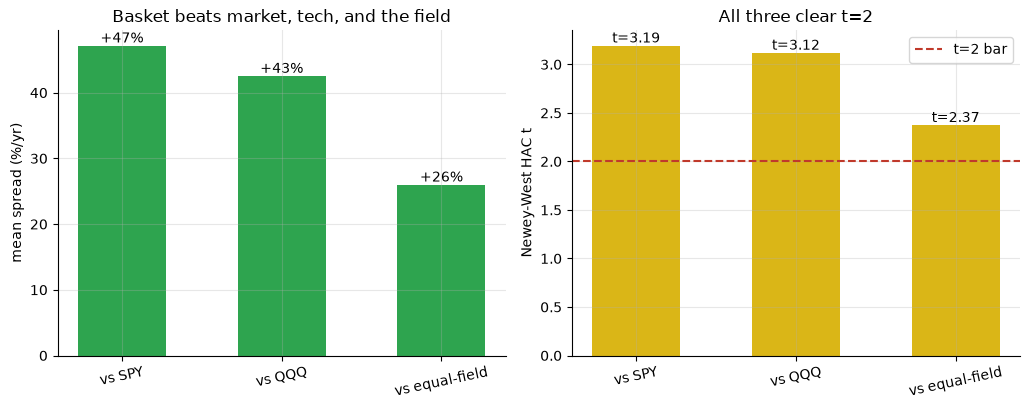

HAC t: {'vs SPY': 3.19, 'vs QQQ': 3.12, 'vs equal-field': 2.37}


In [2]:
if HAVE_REAL:
    tt = [('vs SPY', RACE['test_vs_spy']), ('vs QQQ', RACE['test_vs_qqq']), ('vs equal-field', RACE['test_vs_equal'])]
    labels = [a for a,_ in tt]; means = [b['mean_diff_ann']*100 for _,b in tt]; ts = [b['tstat'] for _,b in tt]
else:
    labels = ['vs SPY','vs QQQ','vs equal-field']
    means = [R['t_spy'][0], R['t_qqq'][0], R['t_eqf'][0]]; ts = [R['t_spy'][1], R['t_qqq'][1], R['t_eqf'][1]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
a1.bar(labels, means, color=GREEN, width=.55)
for i,v in enumerate(means): a1.annotate(f'+{v:.0f}%',(i,v),ha='center',va='bottom')
a1.set_ylabel('mean spread (%/yr)'); a1.set_title('Basket beats market, tech, and the field')
a2.bar(labels, ts, color=AMBER, width=.55); a2.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,v in enumerate(ts): a2.annotate(f't={v:.2f}',(i,v),ha='center',va='bottom')
a2.set_ylabel('Newey-West HAC t'); a2.set_title('All three clear t=2'); a2.legend()
for ax in (a1,a2): ax.tick_params(axis='x', rotation=12)
plt.tight_layout(); plt.show()
print('HAC t:', {l: round(t,2) for l,t in zip(labels,ts)})

> 💡 In plain words: the basket beats the **market** by ~47%/yr (t = 3.19), the **tech tape** by ~42%/yr (t = 3.12), and even the **equal-weight field** — "datacenter stuff in general" — by ~26%/yr (t = 2.37). H₁ is **supported**: this is not a rounding artefact, and it isn't purely market or tech beta. The catch is *not* significance — it's what the significance is **of**.

### 4b · The decisive test — selection reproduces the whole spread

The random-basket distribution (2,000 blind eight-name draws from the field) is the null for *name selection*. The basket and the ex-post 'pick the winners' rule are the green and red lines; the cloud's *position* (well right of zero) is the field's survivorship.

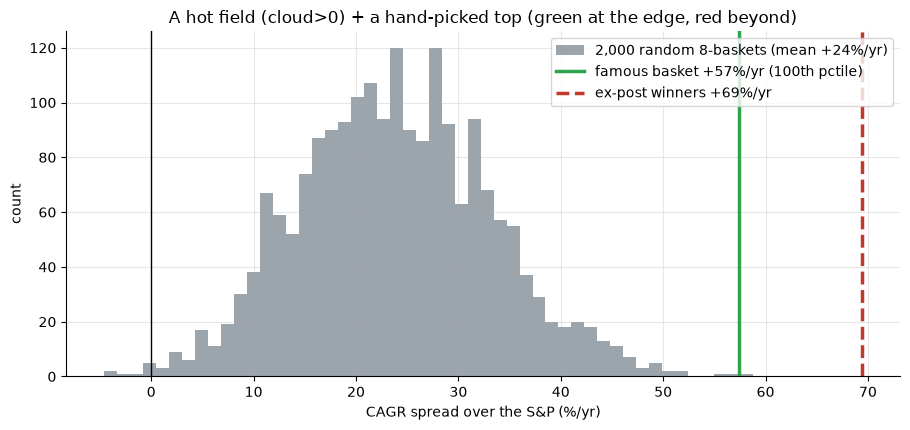

selection share = ex-post/basket = 121%  |  basket percentile = 100


In [3]:
if HAVE_REAL:
    rand = RACE['rand_spread']*100; basket = RACE['basket_cagr_spread']*100
    expost = RACE['expost_cagr_spread']*100; pct = RACE['basket_pctile']
else:
    rng = np.random.default_rng(393); rand = rng.normal(R['rand_mean'], 18, 2000)
    basket = R['basket_spread']; expost = R['expost_spread']; pct = R['pctile']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.hist(rand, bins=50, color=GREY, alpha=.85, label=f'2,000 random 8-baskets (mean +{rand.mean():.0f}%/yr)')
ax.axvline(0, c='k', lw=1)
ax.axvline(basket, c=GREEN, lw=2.5, label=f'famous basket +{basket:.0f}%/yr ({pct:.0f}th pctile)')
ax.axvline(expost, c=RED, lw=2.5, ls='--', label=f'ex-post winners +{expost:.0f}%/yr')
ax.set_xlabel('CAGR spread over the S&P (%/yr)'); ax.set_ylabel('count')
ax.set_title('A hot field (cloud>0) + a hand-picked top (green at the edge, red beyond)')
ax.legend(); plt.tight_layout(); plt.show()
print(f'selection share = ex-post/basket = {expost/basket*100:.0f}%  |  basket percentile = {pct:.0f}')

> 💡 In plain words: the ex-post "pick the winners" rule earns **+69%/yr** — **121%** of the basket's +57%/yr (selection is the *whole* edge, and then some). The basket sits at the **100th percentile** — no random draw beat it. And the cloud's **mean is +24%/yr**: even a blind pick crushed the market, because the field is survivors. H₂ and H₃ rejected.

### 4c · Is it one or two names? — single-name decomposition

Unlike a one-stock theme, the strength here is genuinely spread across several names — which makes the *theme beta* real and puts the weight of the critique on **selection**, not concentration. HAC *t* of each member's monthly excess over SPY:

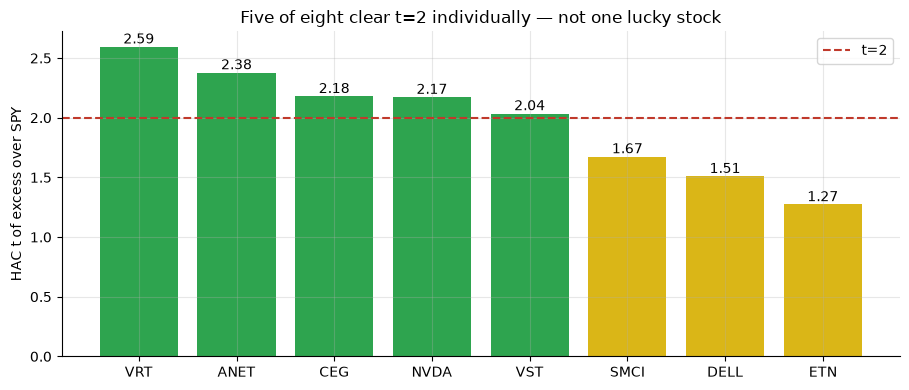

5 of 8 names individually clear t=2


In [4]:
if HAVE_REAL:
    sn = RACE['single_names']
    items = sorted(sn.items(), key=lambda kv: -kv[1]['tstat'])
    names = [k for k,_ in items]; tvals = [v['tstat'] for _,v in items]
else:
    names = [n for n,_,_ in R['names']]; tvals = [t for _,_,t in R['names']]
fig, ax = plt.subplots(figsize=(9.2, 4.0))
cols = [GREEN if t>=2 else AMBER for t in tvals]
ax.bar(names, tvals, color=cols); ax.axhline(2, ls='--', c=RED, label='t=2')
for i,t in enumerate(tvals): ax.annotate(f'{t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('HAC t of excess over SPY'); ax.set_title('Five of eight clear t=2 individually — not one lucky stock')
ax.legend(); plt.tight_layout(); plt.show()
n_sig = sum(1 for t in tvals if t>=2); print(f'{n_sig} of {len(tvals)} names individually clear t=2')

> 💡 In plain words: five of the eight (VRT, ANET, CEG, NVDA, VST) individually clear t = 2 against the market. So this is **not** the GLP-1 case (all one stock) — the theme really did lift several names. That's exactly why the decisive critique is **selection**: it isn't one fluke, it's a *hand-picked top slice of a field that was, in hindsight, on fire* — and you couldn't have specified that slice forward.

### 4d · Faithful-engine & power control — we know the truth here

A deterministic panel where only a *pre-named* basket carries a planted tilt (``alpha_spread``). With **zero** true edge the pre-named basket must stay below t = 2 (no false positive) **while the ex-post placebo still conjures a spread**; with a real planted edge the pre-named basket must light up. Both hold — the engine finds a spread only where one is planted, and manufactures one whenever you select on the outcome.

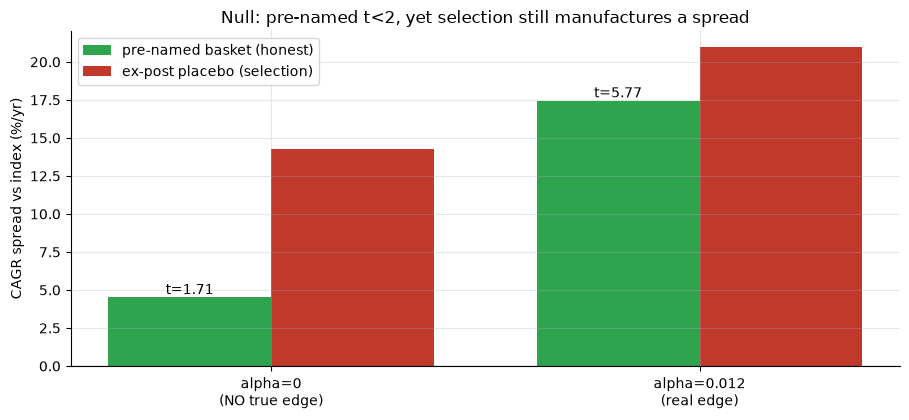

alpha=0.000: pre-named +4.5%/yr (t=+1.71)  ex-post placebo +14.3%/yr
alpha=0.012: pre-named +17.4%/yr (t=+5.77)  ex-post placebo +21.0%/yr


In [5]:
res = []
for a in (0.0, 0.012):
    rdf, b, truth = data.synthetic_panel(alpha_spread=a)
    named = st.basket_returns(rdf, truth['true_basket_cols'])
    expo = st.basket_returns(rdf, st.expost_winners(rdf, k=8, allow_lookahead_selection=True))
    sn = st.summarize(named)['cagr'] - st.summarize(b)['cagr']
    se = st.summarize(expo)['cagr'] - st.summarize(b)['cagr']
    tn = st.hac_tstat_diff(named, b)['tstat']
    res.append((a, sn*100, tn, se*100))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
x = np.arange(len(res)); w=.38
ax.bar(x-w/2, [r[1] for r in res], w, color=GREEN, label='pre-named basket (honest)')
ax.bar(x+w/2, [r[3] for r in res], w, color=RED, label='ex-post placebo (selection)')
for i,r in enumerate(res):
    ax.annotate(f't={r[2]:.2f}',(i-w/2,r[1]),ha='center',va='bottom')
ax.set_xticks(x); ax.set_xticklabels(['alpha=0\n(NO true edge)','alpha=0.012\n(real edge)'])
ax.set_ylabel('CAGR spread vs index (%/yr)'); ax.axhline(0, c='k', lw=.8)
ax.set_title('Null: pre-named t<2, yet selection still manufactures a spread'); ax.legend()
plt.tight_layout(); plt.show()
for a,sn,tn,se in res: print(f'alpha={a:.3f}: pre-named {sn:+.1f}%/yr (t={tn:+.2f})  ex-post placebo {se:+.1f}%/yr')

> 💡 In plain words: with **no** real edge the pre-named basket sits at **t = 1.71** (below 2 — no false positive) yet the ex-post placebo still conjures **+14%/yr** from pure selection; only a genuine planted tilt drives the honest basket to **t = 5.77**. The machinery is faithful — and the real-tape lesson is that a *selected* basket can post a huge spread with **no** forward-specifiable edge underneath.

## 5 · The verdict

- **Signal `MIXED`** — basket−SPY **+47%/yr**, HAC **t = 3.19** (n=52); **t = 3.12** vs QQQ, **t = 2.37** vs the equal-field; five names clear t=2 individually. Real on the realised tape — but **look-ahead / survivorship selected** on **one short ~4-year regime**. A `WEAK` going-forward case in a strong in-sample *t* ⇒ `MIXED`.
- **Tradability `MIRAGE`** — costs immaterial (net CAGR unchanged to the decimal). The ex-post rule reproduces **121%** of the spread, the basket is the **100th percentile** of random draws, and even a *blind* eight beats SPY by **+24%/yr** (the field is survivors). The +57%/yr is a number only hindsight can buy.
- **Ride the build-out? `BUSTED`** — the +57%/yr decomposes into ≈+24%/yr (hot field, survivorship) + ≈+34%/yr (name selection); neither is forward-specifiable. **Study 355 (Mag-7) inverted into a theme** — same selection pathology, datacenter costume.

## 6 · Could you trade it? — the forward-vs-hindsight gap

The operational truth in one decomposition: split the realised spread into the part a blind investor would have earned (the field's survivorship) and the part that requires hindsight (name selection). Only the first is even arguably forward-tradable — and it's itself an artefact of which names *survived* into today's field.

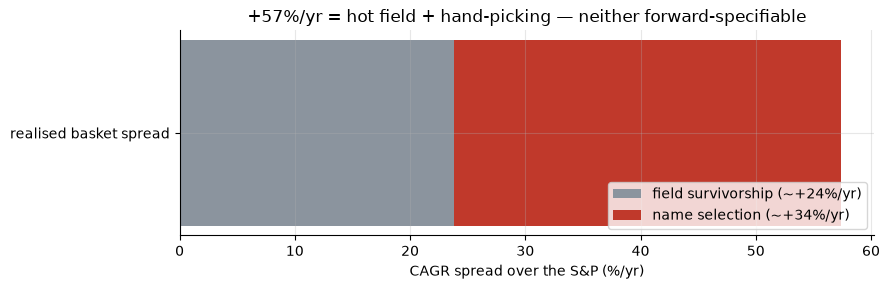

survivorship ~+24%/yr  +  selection ~+34%/yr  =  +57%/yr realised


In [6]:
if HAVE_REAL:
    field_part = float(RACE['rand_spread'].mean())*100
    total = RACE['basket_cagr_spread']*100
else:
    field_part = R['rand_mean']; total = R['basket_spread']
sel_part = total - field_part
fig, ax = plt.subplots(figsize=(9.0, 3.0))
ax.barh(['realised basket spread'], [field_part], color=GREY, label=f'field survivorship (~+{field_part:.0f}%/yr)')
ax.barh(['realised basket spread'], [sel_part], left=[field_part], color=RED, label=f'name selection (~+{sel_part:.0f}%/yr)')
ax.set_xlabel('CAGR spread over the S&P (%/yr)'); ax.set_xlim(0, total*1.05)
ax.set_title(f'+{total:.0f}%/yr = hot field + hand-picking — neither forward-specifiable')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()
print(f'survivorship ~+{field_part:.0f}%/yr  +  selection ~+{sel_part:.0f}%/yr  =  +{total:.0f}%/yr realised')

> 💡 In plain words: of the **+57%/yr**, roughly **+24%/yr** is *"any random pick of this field beat the market"* — but that field only exists because those names **survived and re-rated** (survivorship); a 2019 field would have included names that since cratered. The remaining **~+34%/yr** is **name selection** — keeping the winners. There is no slicing of this that a 2019 investor could have *specified in advance*: the rarity that makes the basket impressive is exactly the hindsight that makes it untradable.

## 7 · Going further

- **The mega-cap original.** [Study 355 — Magnificent-Seven](../../355-magnificent-seven/): the same selection decomposition on the Mag 7; reading them together is the cleanest demo that thematic baskets are realised rankings, not factors.
- **The single-name limit.** [Study 356 — GLP-1 basket](../../356-glp1-basket/): a theme basket whose alpha collapses entirely to one stock.
- **The mechanics.** [Study 350 — Dartboard-Portfolio](../../350-dartboard-portfolio/) and [Study 345 — Survivorship-Bias](../../345-survivorship-bias/) isolate the selection and survivorship artefacts this basket inherits.
- **Pre-register it.** Specify a datacenter/power basket from *pre-2022* information only, freeze it, and test it forward against a random pick of the field; the look-ahead vanishes and (the null suggests) so does most of the edge.

*The reproducible core is offline and deterministic; the field & membership are an explicit current-membership projection. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*